<a href="https://colab.research.google.com/github/25041068-boop/Probabilidad/blob/main/Unidad1/Practica_3_Tabla_de_frecuencias_y_regla_de_Sturges_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilidad y estaditica
# **Unidad 1**
## Practica 3: **Tabla de frecuencias y regla de Sturges.**

Docente: Jose Gabriel Rodriguez Rivas

Alumno: Ivan Rafael Ortega Corral

In [28]:
# basado en el LIBRO estadistica para administración pagina 12
# creamos una lista vacia que representa la edad de 100 personas
import random
import matplotlib.pyplot as plt


edades = []

# Hacemos un ciclo para generar 100 numeros aleatorios que representan la edad de las personas
for i in range(100):
    # generamos un numero aleatorio con la funcion randint y lo guardamos en la variable
    # numero_aleatorio
    numero_aleatorio = random.randint(18, 70)

    # Agregamos el numero aleatorio a la lista de valores
    edades.append(numero_aleatorio)

print(edades)

[70, 20, 37, 60, 69, 53, 30, 41, 30, 59, 43, 18, 20, 59, 55, 43, 23, 57, 70, 58, 57, 42, 53, 63, 39, 57, 45, 28, 34, 42, 33, 38, 41, 26, 35, 36, 54, 67, 47, 70, 36, 30, 36, 40, 38, 32, 18, 69, 19, 41, 26, 31, 19, 18, 70, 61, 31, 50, 24, 59, 29, 55, 50, 33, 59, 54, 23, 19, 31, 53, 69, 53, 41, 26, 65, 44, 45, 56, 48, 35, 70, 48, 60, 35, 67, 28, 49, 59, 38, 48, 39, 44, 35, 53, 24, 22, 49, 61, 46, 43]


In [29]:
import pandas as pd

# Crear un DataFrame de pandas con los números aleatorios
df = pd.DataFrame(edades, columns=['Edad'])
df.head()

,Edad
0,70
1,20
2,37
3,60
4,69


In [30]:
# Calcular la tabla de distribución de frecuencias
tabla_frecuencias = df['Edad'].value_counts().reset_index()
tabla_frecuencias.columns = ['Edad', 'Frecuencia']
tabla_frecuencias = tabla_frecuencias.sort_values(by='Edad')

# Imprimir la tabla de distribución de frecuencias
print("Tabla de Distribución de Frecuencias:")
tabla_frecuencias

Tabla de Distribución de Frecuencias:


,Edad,Frecuencia
6,18,3
15,19,3
19,20,2
42,22,1
25,23,2
16,24,2
9,26,3
23,28,2
39,29,1
5,30,3


In [31]:
tabla_frecuencias['Frec Relativa'] = tabla_frecuencias['Frecuencia'] / 100
tabla_frecuencias

,Edad,Frecuencia,Frec Relativa
6,18,3,0.03
15,19,3,0.03
19,20,2,0.02
42,22,1,0.01
25,23,2,0.02
16,24,2,0.02
9,26,3,0.03
23,28,2,0.02
39,29,1,0.01
5,30,3,0.03


In [32]:
tabla_frecuencias['Frec Porcentual'] = tabla_frecuencias['Frecuencia'] / 100 * 100
tabla_frecuencias

,Edad,Frecuencia,Frec Relativa,Frec Porcentual
6,18,3,0.03,3.0
15,19,3,0.03,3.0
19,20,2,0.02,2.0
42,22,1,0.01,1.0
25,23,2,0.02,2.0
16,24,2,0.02,2.0
9,26,3,0.03,3.0
23,28,2,0.02,2.0
39,29,1,0.01,1.0
5,30,3,0.03,3.0


In [33]:
tabla_frecuencias['Frec Acumulada'] = tabla_frecuencias['Frecuencia'].cumsum()
tabla_frecuencias

,Edad,Frecuencia,Frec Relativa,Frec Porcentual,Frec Acumulada
6,18,3,0.03,3.0,3
15,19,3,0.03,3.0,6
19,20,2,0.02,2.0,8
42,22,1,0.01,1.0,9
25,23,2,0.02,2.0,11
16,24,2,0.02,2.0,13
9,26,3,0.03,3.0,16
23,28,2,0.02,2.0,18
39,29,1,0.01,1.0,19
5,30,3,0.03,3.0,22


In [34]:
# Importamos la librería math de funciones matemáticas
import math

# Volvemos a usar la lista edades
print(edades)

[70, 20, 37, 60, 69, 53, 30, 41, 30, 59, 43, 18, 20, 59, 55, 43, 23, 57, 70, 58, 57, 42, 53, 63, 39, 57, 45, 28, 34, 42, 33, 38, 41, 26, 35, 36, 54, 67, 47, 70, 36, 30, 36, 40, 38, 32, 18, 69, 19, 41, 26, 31, 19, 18, 70, 61, 31, 50, 24, 59, 29, 55, 50, 33, 59, 54, 23, 19, 31, 53, 69, 53, 41, 26, 65, 44, 45, 56, 48, 35, 70, 48, 60, 35, 67, 28, 49, 59, 38, 48, 39, 44, 35, 53, 24, 22, 49, 61, 46, 43]


In [35]:
# Crear un DataFrame con las edades
df = pd.DataFrame({'Edad': edades})
df

,Edad
0,70
1,20
2,37
3,60
4,69
...,...
95,22
96,49
97,61
98,46


In [36]:
# Calcular el número de intervalos utilizando la regla de Sturges
n = len(edades)
K = int(1 + math.log2(n))

print("Valor de n =", n, "\nNúmero de intervalos =", K)

Valor de n = 100 
Número de intervalos = 7


In [37]:
# Crear la tabla de frecuencia

tabla_frecuencia = pd.cut(
    df['Edad'],
    bins=K,
    include_lowest=True
).value_counts().reset_index()

tabla_frecuencia.columns = ['Clase', 'Frec']
tabla_frecuencia

,Clase,Frec
0,"(32.857, 40.286]",17
1,"(47.714, 55.143]",16
2,"(40.286, 47.714]",15
3,"(55.143, 62.571]",14
4,"(17.947, 25.429]",13
5,"(25.429, 32.857]",13
6,"(62.571, 70.0]",12


In [38]:
# Ordenar la tabla de frecuencia por el intervalo
tabla_frecuencia = tabla_frecuencia.sort_values(by='Clase')
tabla_frecuencia

,Clase,Frec
4,"(17.947, 25.429]",13
5,"(25.429, 32.857]",13
0,"(32.857, 40.286]",17
2,"(40.286, 47.714]",15
1,"(47.714, 55.143]",16
3,"(55.143, 62.571]",14
6,"(62.571, 70.0]",12


In [39]:
# Generar columnas siguientes
tabla_frecuencia['Frec Rel'] = tabla_frecuencia['Frec'] / n
tabla_frecuencia['Frec Porc'] = tabla_frecuencia['Frec'] / n * 100
tabla_frecuencia['Frec Ac'] = tabla_frecuencia['Frec'].cumsum()
tabla_frecuencia['Frec Rel Ac'] = tabla_frecuencia['Frec Rel'].cumsum()
tabla_frecuencia['Frec Porc Ac'] = tabla_frecuencia['Frec Porc'].cumsum()

# Mostrar la tabla de frecuencia
print(tabla_frecuencia)

              Clase  Frec  Frec Rel  Frec Porc  Frec Ac  Frec Rel Ac  \
4  (17.947, 25.429]    13      0.13       13.0       13         0.13   
5  (25.429, 32.857]    13      0.13       13.0       26         0.26   
0  (32.857, 40.286]    17      0.17       17.0       43         0.43   
2  (40.286, 47.714]    15      0.15       15.0       58         0.58   
1  (47.714, 55.143]    16      0.16       16.0       74         0.74   
3  (55.143, 62.571]    14      0.14       14.0       88         0.88   
6    (62.571, 70.0]    12      0.12       12.0      100         1.00   

   Frec Porc Ac  
4          13.0  
5          26.0  
0          43.0  
2          58.0  
1          74.0  
3          88.0  
6         100.0  


Text(0.5, 1.0, 'Histograma de edades basado en la funcion de matplotlib con valores estandar')

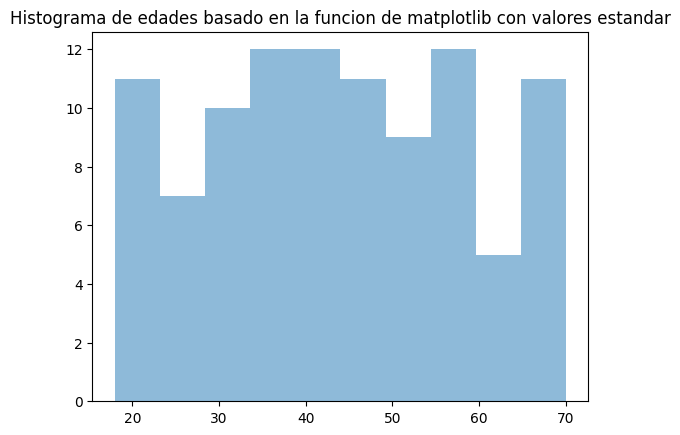

In [40]:
plt.hist(edades, alpha = 0.5)
plt.title("Histograma de edades basado en la funcion de matplotlib con valores estandar")

Text(0, 0.5, 'Frecuencia')

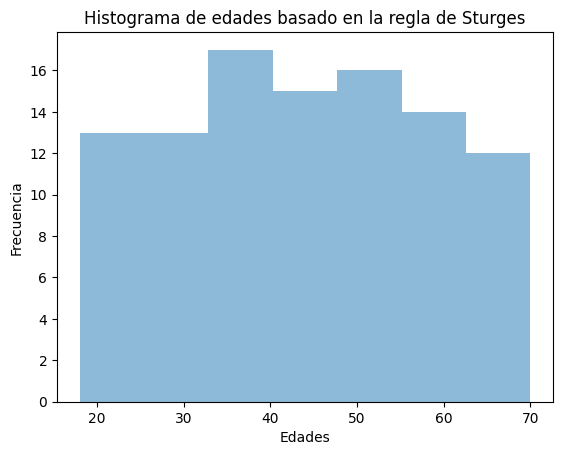

In [41]:
# Crear un histograma basado en la tabla de frecuencia
plt.hist(df['Edad'], bins=K, alpha = 0.5)
plt.title('Histograma de edades basado en la regla de Sturges')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')